In [1]:
%matplotlib inline

import pandas as pd
import stumpy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
from matplotlib.patches import Rectangle
import datetime as dt

plt.style.use('https://raw.githubusercontent.com/TDAmeritrade/stumpy/main/docs/stumpy.mplstyle')

In [2]:
sales_df = pd.read_csv("C://Users//athen//Downloads//archive (2)//sales-of-shampoo-over-a-three-ye.csv")
sales_df.head()

,Month,Sales of shampoo over a three year period
0,1-Jan,266.0
1,1-Feb,145.9
2,1-Mar,183.1
3,1-Apr,119.3
4,1-May,180.3


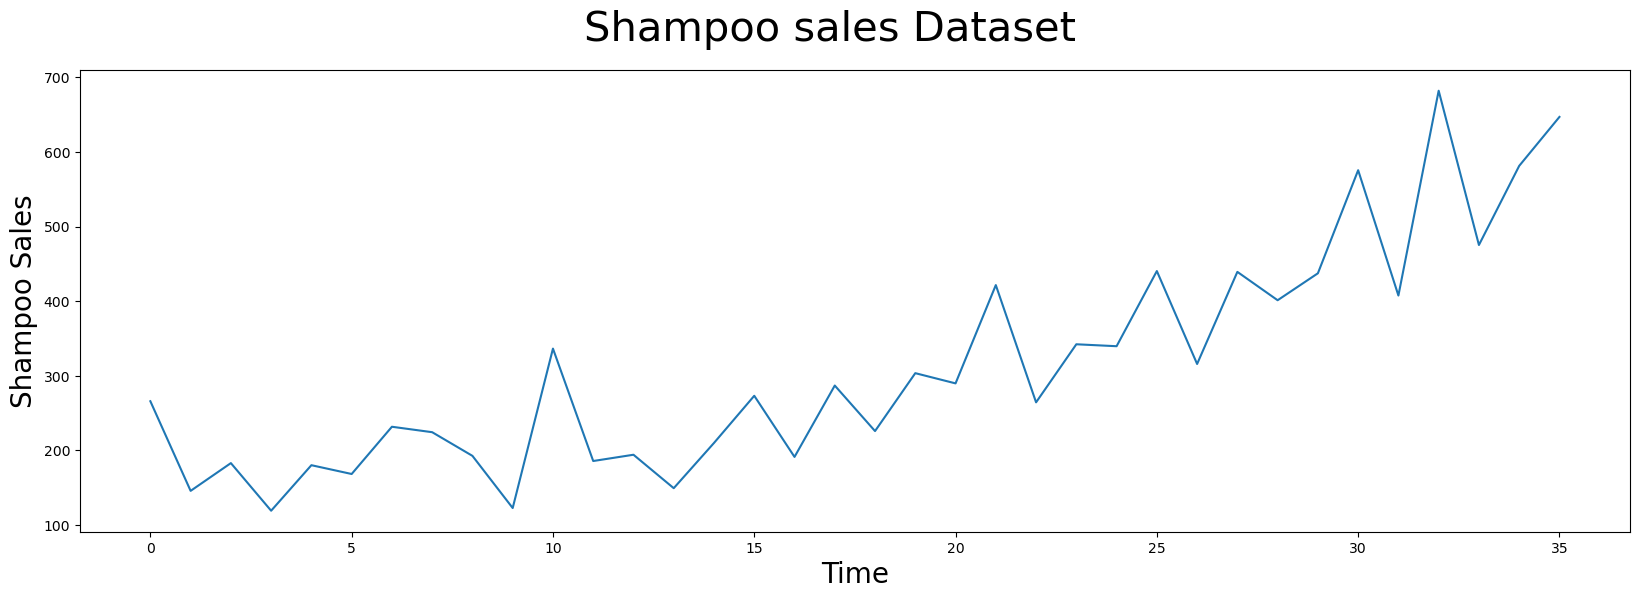

In [3]:
plt.suptitle('Shampoo sales Dataset', fontsize='30')
plt.xlabel('Time', fontsize ='20')
plt.ylabel('Shampoo Sales', fontsize='20')
plt.plot(sales_df['Sales of shampoo over a three year period'].values)
plt.show()

In [4]:
m=7

In [5]:
mp = stumpy.stump(sales_df['Sales of shampoo over a three year period'], m)

In [6]:
motif_idx = np.argsort(mp[:, 0])[0]

print(f"The motif is located at index {motif_idx}")

The motif is located at index 22


In [7]:
nearest_neighbor_idx = mp[motif_idx, 1]

print(f"The nearest neighbor is located at index {nearest_neighbor_idx}")

The nearest neighbor is located at index 18


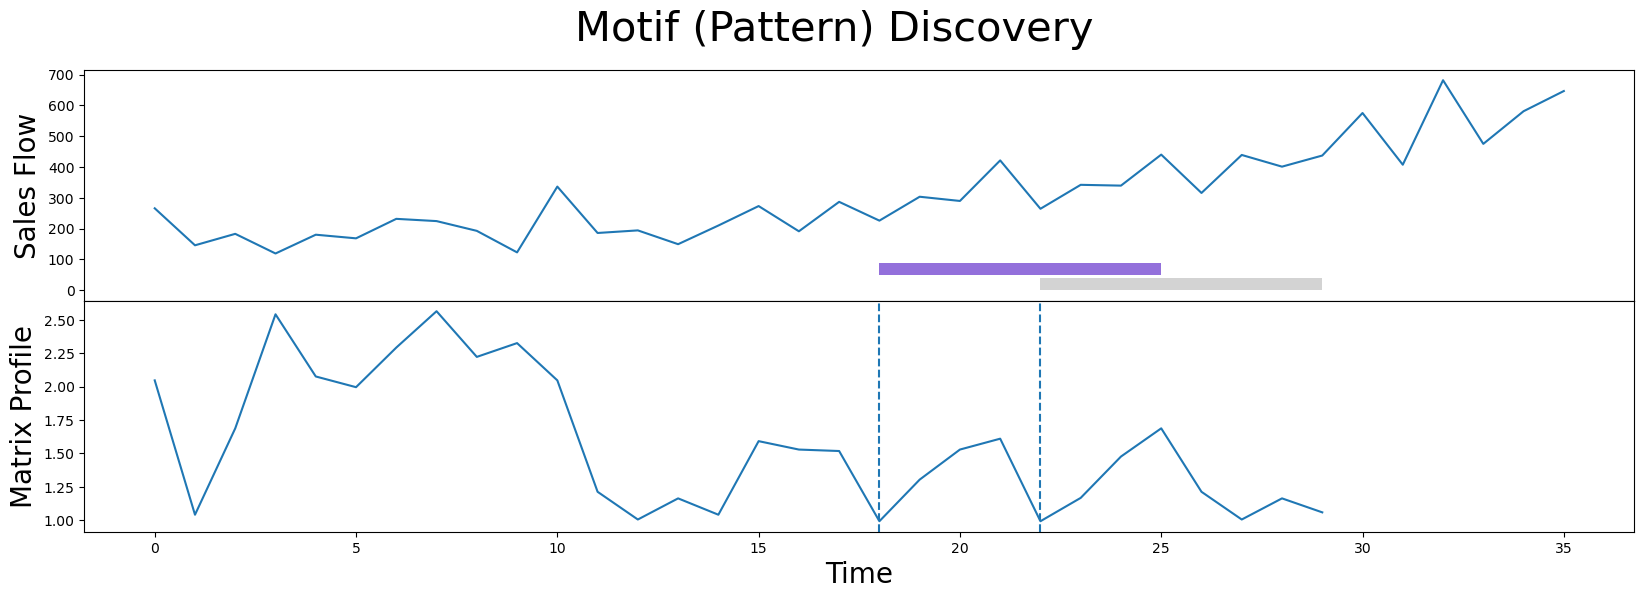

In [8]:
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
plt.suptitle('Motif (Pattern) Discovery', fontsize='30')

axs[0].plot(sales_df['Sales of shampoo over a three year period'].values)
axs[0].set_ylabel('Sales Flow', fontsize='20')
rect = Rectangle((motif_idx, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)
rect = Rectangle((nearest_neighbor_idx, 50), m, 40, facecolor='#9370DB')
axs[0].add_patch(rect)
axs[1].set_xlabel('Time', fontsize ='20')
axs[1].set_ylabel('Matrix Profile', fontsize='20')
axs[1].axvline(x=motif_idx, linestyle="dashed")
axs[1].axvline(x=nearest_neighbor_idx, linestyle="dashed")
axs[1].plot(mp[:, 0])
plt.show()

In [9]:
mp[motif_idx, 0]

0.9929284097635019

In [10]:
discord_idx = np.argsort(mp[:, 0])[-1]

print(f"The discord is located at index {discord_idx}")

The discord is located at index 7


In [11]:
nearest_neighbor_distance = mp[discord_idx, 0]

print(f"The nearest neighbor subsequence to this discord is {nearest_neighbor_distance} units away")


The nearest neighbor subsequence to this discord is 2.565245907660723 units away


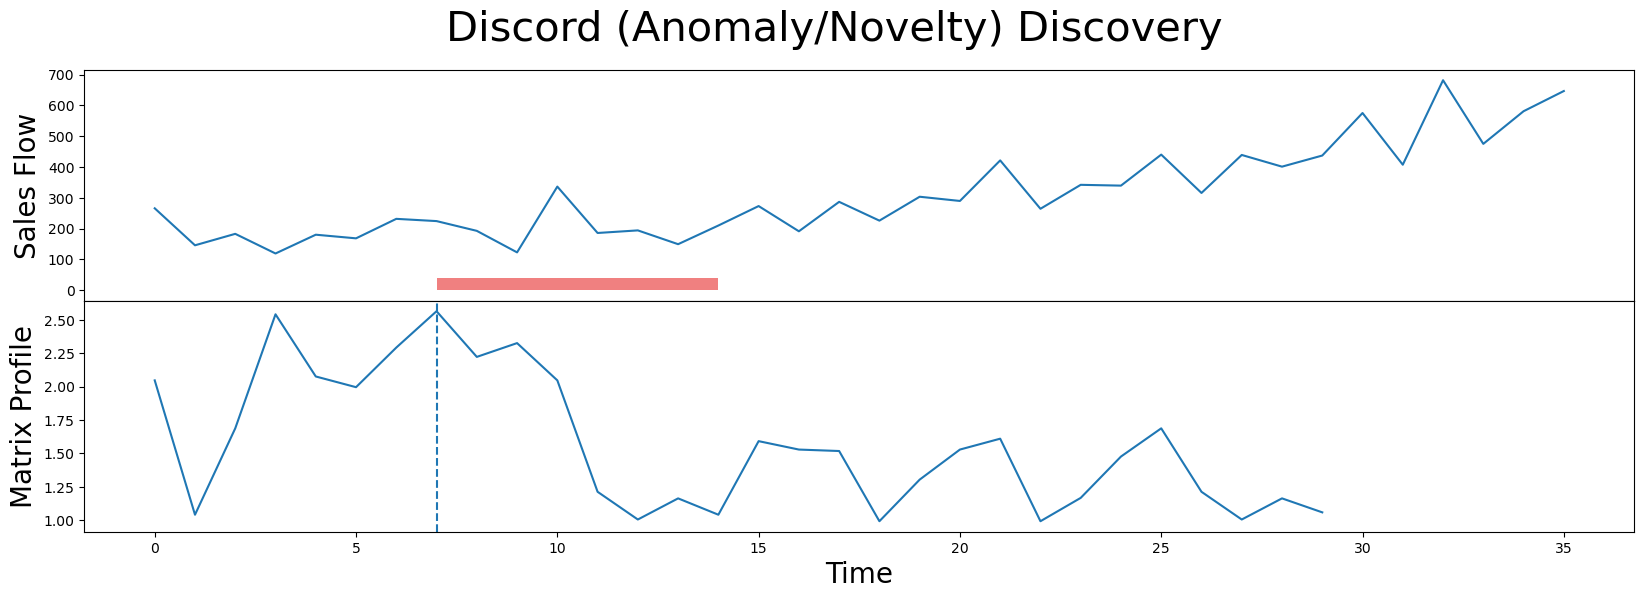

In [12]:
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
plt.suptitle('Discord (Anomaly/Novelty) Discovery', fontsize='30')

axs[0].plot(sales_df['Sales of shampoo over a three year period'].values)
axs[0].set_ylabel('Sales Flow', fontsize='20')
rect = Rectangle((discord_idx, 0), m, 40, facecolor='lightcoral')
axs[0].add_patch(rect)
axs[1].set_xlabel('Time', fontsize ='20')
axs[1].set_ylabel('Matrix Profile', fontsize='20')
axs[1].axvline(x=discord_idx, linestyle="dashed")
axs[1].plot(mp[:, 0])
plt.show()